In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pymc as pm
import pymc_extras as pmx
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import matplotlib.cm as cm
import arviz as az
from sklearn.preprocessing import StandardScaler
import pytensor.tensor as pt
import matplotlib.cm as cm
import regionmask
import cartopy.crs as ccrs
from geopy.geocoders import Nominatim
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pymc import Minibatch
import seaborn as sns
random_seed=123
np.random.seed(random_seed)
import os,sys,glob
from importlib import reload

In [2]:
import logging
# Set PyMC logger to WARNING or ERROR to suppress info messages
logger = logging.getLogger("pymc")
logger.setLevel(logging.WARNING)

# Metrics
Each file contains:
* AnnualMean:  Gamma
* RX1day: Monthly maximum 1-day precipitation: GEV
* RX5day: Monthly maximum consecutive 5-day precipitation: GEV
* R50: Monthly number of days with daily rainfall exceeding 50 mm: Poisson
* WetDayMedian: ?? Maybe Gamma?

In [3]:
def model_type(index):
    MODELS={}
    MODELS["AnnualMean"]="Gamma"
    MODELS["RX1day"] = "GEV"
    MODELS["RX5day"] = "GEV"
    MODELS["R50"] = "Poisson"

# Import model builders

In [4]:
from trend_detector import ar6models,plotting

In [5]:
from trend_detector.io import get_data_path
reload(ar6models)

<module 'trend_detector.ar6models' from '/Users/akshayrajeev/Stuff/Projects/IMERG_trends/PMM/trend_detector/ar6models.py'>

# Eastern North America
As an example, let's look at RX1day in Eastern North America

In [25]:
region="ENA"
factory = ar6models.AR6ModelFactory(region, "RX1day")

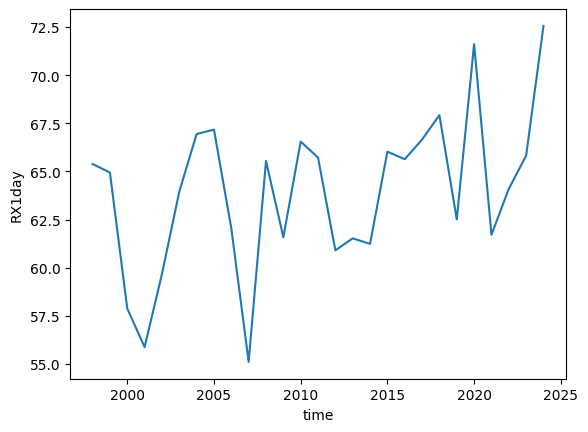

In [26]:
factory.get_data().plot()

## Standard model
First, assume RX1day $x$ is stationary: 
$$
G(x) = \exp\left\{ \left[ 1 - \xi \left( \frac{x - \mu}{\sigma} \right) \right]^{-1/\xi} \right\}
$$

In [27]:
standardmodel,standardtrace=factory.build_and_sample("standard")

Building standard model
Sampling standard model


Output()

### Parameters
We get full posteriors for each of the parameters:
* $\mu$: "typical" value of RX1day
* $\sigma$: variability in RX1day
* $\xi$: tail behavior (how extreme can it get?)

array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'sigma'}>,
       <Axes: title={'center': 'xi'}>], dtype=object)

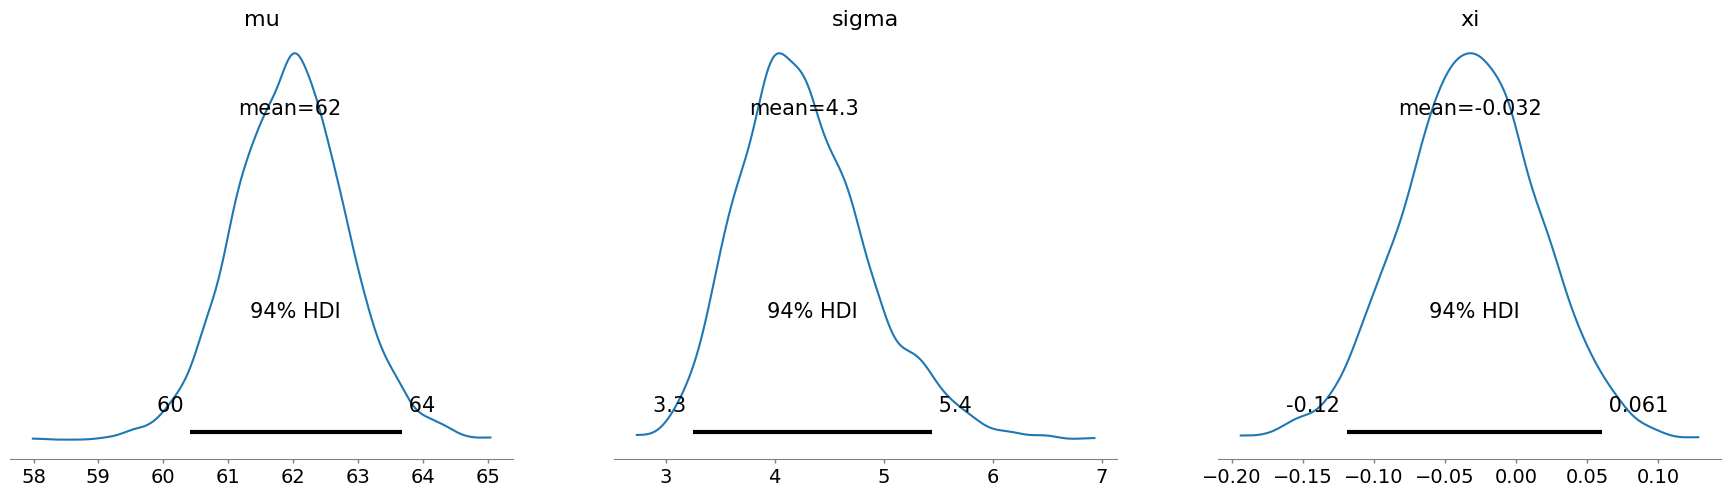

In [28]:
az.plot_posterior(standardtrace,var_names=["mu","sigma","xi"])

### Return levels
Estimates of the 25 year and 100 year return levels:
$$
z_{p}
=
\mu
-
\frac{\sigma}{\xi}
\left(
1 - \left[-\log(1 - p)\right]^{-\xi}
\right)
$$

array([<Axes: >], dtype=object)

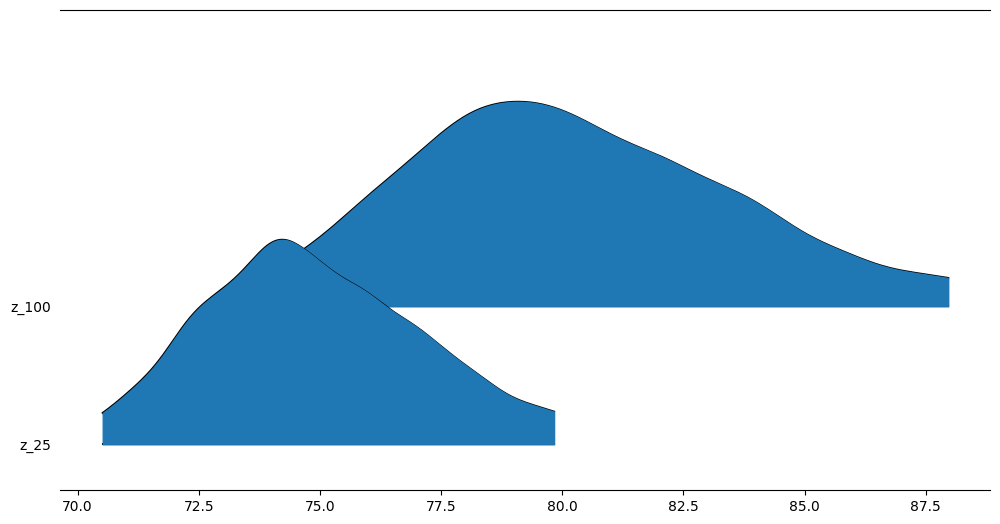

In [10]:
az.plot_forest(standardtrace,var_names=["z_100","z_25"],kind="ridgeplot",combined=True)

## Nonstationary trend model
Now fit a GEV with $\mu(t)= \alpha+ \beta t$

In [11]:
trendmodel,trendtrace=factory.build_and_sample("trend")

Building trend model
Sampling trend model


Output()

There's pretty strong evidence for a trend here- 99% of the posterior mass is shifted away from zero.

<Axes: title={'center': 'beta'}>

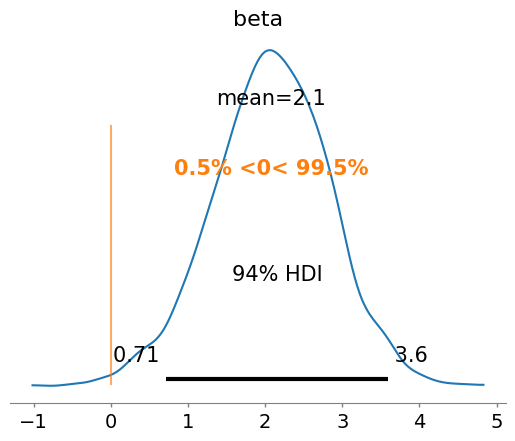

In [12]:
az.plot_posterior(trendtrace,var_names=["beta"],ref_val=0)

And we can predict future extremes:

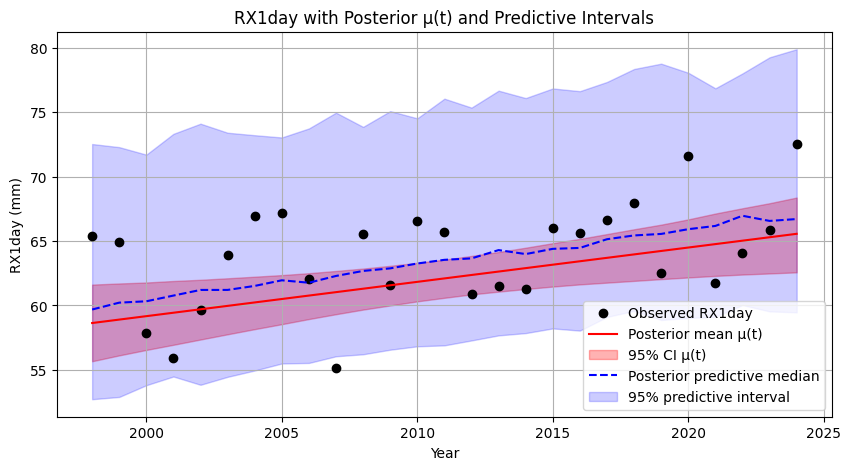

In [13]:
 plotting.plot_GEV_trend_with_predictive(factory.get_data(), trendtrace)

# Switch point model


In [15]:
switchmodel,switchtrace=factory.build_and_sample("switchpoint",lower=1998,upper=2024,rebuild=True,resample=True)


Building switchpoint model
Sampling switchpoint model


Output()

There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The switchpoint model assumes a sudden jump from one distribution (i.e. a GEV characterized by $mu_{early}$) to another (i.e. a GEV characterized by $mu_{late}$) at a discrete time.  In this case, the model learns that the typical RX1day early in the record (blue) is around 60mmm while it's around 64 mm after the jump (orange).  Constrast this with the standard (no trend, no changepoint) model (green).

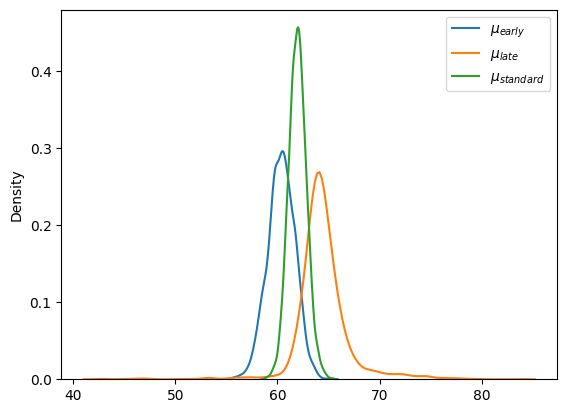

In [16]:
sns.kdeplot(switchtrace.posterior.mu_early.values.flatten(),label=r"$\mu_{early}$")
sns.kdeplot(switchtrace.posterior.mu_late.values.flatten(),label=r"$\mu_{late}$")
sns.kdeplot(standardtrace.posterior.mu.values.flatten(),label=r"$\mu_{standard}$")
plt.legend()


But the model can't really tell where the switchpoint is.  There is quite a lot of posterior mass around 2014- interesting, since we know that's where the changeover between TRMM/GPM happens in IMERG.

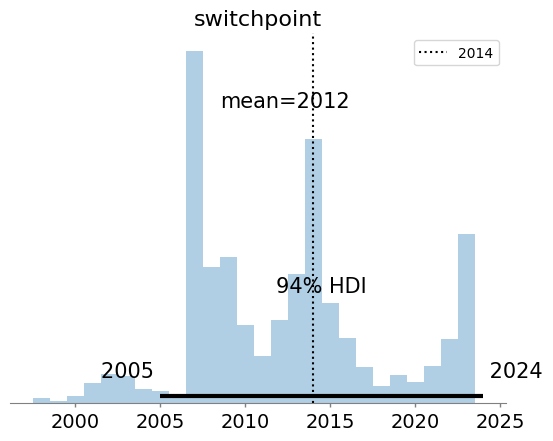

In [17]:
az.plot_posterior(switchtrace,var_names=["switchpoint"],bins=np.arange(1998,2025))
plt.axvline(2014,c="k",ls=":",label="2014")
plt.legend()

So let's use the information we know. We'll restrict the changepoint to be where we think it should be:

In [18]:
switchmodel2014,switchtrace2014=factory.build_and_sample("switchpoint",lower=2014,upper=2014,rebuild=True,resample=True)

Building switchpoint model
Sampling switchpoint model


Output()

/Users/akshayrajeev/anaconda3/envs/pmm/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


This shifts and  narrows the posteriors a little, because we're no longer sampling over uncertainty in the switchpoint.

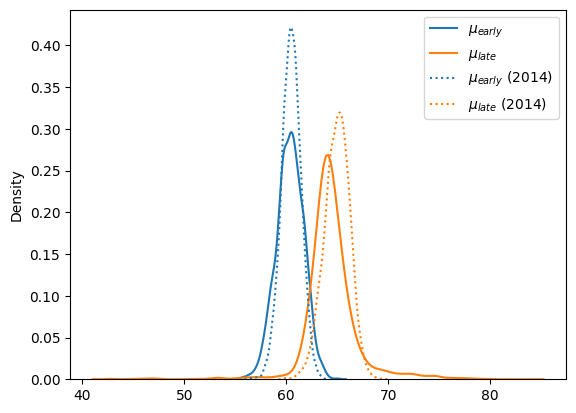

In [19]:
sns.kdeplot(switchtrace.posterior.mu_early.values.flatten(),label=r"$\mu_{early}$")
sns.kdeplot(switchtrace.posterior.mu_late.values.flatten(),label=r"$\mu_{late}$")
sns.kdeplot(switchtrace2014.posterior.mu_early.values.flatten(),label=r"$\mu_{early}$ (2014)",color=cm.tab10(0),ls=":")
sns.kdeplot(switchtrace2014.posterior.mu_late.values.flatten(),label=r"$\mu_{late}$ (2014)",color=cm.tab10(1),ls=":")
#sns.kdeplot(standardtrace.posterior.mu.values.flatten(),label=r"$\mu_{standard}$")
plt.legend()

## Which model best explains the data?
A leave-one-out comparison ranks switchpoint as the best model, but it's pretty much tied with trend.  The data isn't sufficient to differentiate between them.  They ae distinct from the standard model, despite having more parameters.

In [20]:
factory.compare(["standard","trend","switchpoint"])

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
switchpoint,0,-77.500356,2.619314,0.000000,0.762888,2.950627,0.000000,False,log
trend,1,-77.968902,2.852637,0.468546,0.237112,3.342780,1.345461,False,log
standard,2,-80.476693,2.033750,2.976337,0.000000,3.635750,1.892323,False,log


In Bayesian model comparison, the model rank (based on expected log predictive density) only orders models by their point estimate of predictive accuracy, whereas the stacking weight accounts for both predictive performance and model complexity. The model with the highest stacking weight is preferred because it has the greatest expected predictive utility for new data, reflecting the combination of fit and parsimony, rather than just a potentially noisy point estimate.